In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, HistGradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

def loadData(trainPath="TRAIN.csv", testPath="TEST.csv"):
    train=pd.read_csv(trainPath)
    test=pd.read_csv(testPath)
    
    #finding if any missing values
    
    print(f"Train shape:{train.shape},Test shape:{test.shape}")
    print(f"Missing values in Train:{train.isnull().sum().sum()}")
    print(f"Missing values in Test:{test.isnull().sum().sum()}")
    XTrain=train.drop(columns=['Class'])
    yTrain=train['Class']
    XTest=test.drop(columns=['ID'])
    testIds=test['ID']
    return XTrain,yTrain, XTest,testIds

print("LOADING DATA")
X_train_raw, y_train,X_test_raw,test_ids=loadData(
    "C:\\Users\\komal\\Documents\\alrIEEEna_26_dataset\\MLChallengeDataset\\TRAIN.csv", 
    "C:\\Users\\komal\\Documents\\alrIEEEna_26_dataset\\MLChallengeDataset\\TEST.csv"
)

LOADING DATA
Train shape:(43776, 48),Test shape:(10944, 48)
Missing values in Train:0
Missing values in Test:0


In [7]:
#instead of deleting outliers, I just set a maximum limit.
#If a number is way too high, I just pull it down to that limit. 
#This fixes the broken data but keeps the real warning signs safe.
def handle_outliers(X_train, X_test):
    print("Outlier detection")
    X_train_capd=X_train.copy()
    X_test_capd=X_test.copy()

    total_outliers=0
    feature_cols=[c for c in X_train.columns if c.startswith('F')]
    
    for col in feature_cols:
        q1=X_train[col].quantile(0.25)
        q3=X_train[col].quantile(0.75)
        IQR=q3-q1
        lower_bound=q1-1.5*IQR
        upper_bound=q3+1.5*IQR
        
        otlrs_cnt=((X_train[col]<lower_bound)|(X_train[col]>upper_bound)).sum()
        total_outliers+=otlrs_cnt
        
        lwr_cap=X_train[col].quantile(0.01)
        upr_cap=X_train[col].quantile(0.99)
        
        X_train_capd[col]=np.clip(X_train[col],lwr_cap,upr_cap)
        X_test_capd[col]=np.clip(X_test[col],lwr_cap,upr_cap)
        
    print(f"Detected {total_outliers} outlier.")
    return X_train_capd,X_test_capd

def featureEngineering(df):
    df_eng=df.copy()

    ftr_cols = []
    for col in df_eng.columns:
        if col.startswith('F'):
            ftr_cols.append(col)
    new_ftr={}
    """
    Rather than checking every sensor value one by one, we create a quick
    summary of the machine’s current state. We calculate the mean to get the
    overall level, use standard deviation to see how much the readings vary,
    and check skewness/kurtosis to catch unusual spikes. We also keep the
    maximum and minimum readings. These statistics help us quickly notice
    when the machine starts behaving abnormally.
    """
    new_ftr['sensor_mean']=df_eng[ftr_cols].mean(axis=1)
    new_ftr['sensor_std']=df_eng[ftr_cols].std(axis=1)
    new_ftr['sensor_skew']=df_eng[ftr_cols].skew(axis=1)
    new_ftr['sensor_kurt']=df_eng[ftr_cols].kurtosis(axis=1)
    new_ftr['sensor_min']=df_eng[ftr_cols].min(axis=1)
    new_ftr['sensor_max']=df_eng[ftr_cols].max(axis=1)
    new_ftr['sensor_median']=df_eng[ftr_cols].median(axis=1)
    new_ftr['sensor_q25']=df_eng[ftr_cols].quantile(0.25, axis=1)
    new_ftr['sensor_q75']=df_eng[ftr_cols].quantile(0.75, axis=1)
    
    for i in range(1, len(ftr_cols)):
        prev_col = ftr_cols[i - 1]
        curr_col = ftr_cols[i]

    roc_name = 'roc_' + prev_col + '_' + curr_col
    new_ftr[roc_name] = df_eng[curr_col] - df_eng[prev_col]


    for col in ftr_cols:
        dev_name='dev_' + col
        new_ftr[dev_name]=df_eng[col]-new_ftr['sensor_mean']


    new_ftr_df = pd.DataFrame(new_ftr)
    result_df = pd.concat([df_eng, new_ftr_df], axis=1)

    return result_df

def feature_selection(X_train, y_train, X_test, drop_bottom_pct=0.20):
    print(f"Dropping {drop_bottom_pct*100}% of features")
    selc_model = LGBMClassifier(n_estimators=150, random_state=42, n_jobs=-1, verbose=-1)
    selc_model.fit(X_train,y_train)
    
    ftr_imp_df =pd.DataFrame({
        'Feature':X_train.columns, 
        'Importance':selc_model.feature_importances_
    }).sort_values(by='Importance',ascending=False)

    num_ftr_to_keep=int(len(X_train.columns) * (1-drop_bottom_pct))
    top_features=ftr_imp_df.head(num_ftr_to_keep)['Feature'].tolist()
    
    features_dropped = len(X_train.columns)-num_ftr_to_keep
    print(f"Dropped {features_dropped}\nKept features {num_ftr_to_keep}")

    return X_train[top_features].copy(), X_test[top_features].copy()

X_train_capped, X_test_capped=handle_outliers(X_train_raw, X_test_raw)

XTrainEng=featureEngineering(X_train_capped)
XTestEng=featureEngineering(X_test_capped)

X_train_clean, X_test_clean=feature_selection(XTrainEng, y_train, XTestEng, drop_bottom_pct=0.15)

Outlier detection
Detected 272392 outlier.
Dropping 15.0% of features
Dropped 16
Kept features 88


In [8]:
def model_selecsn(X_train,y_train):
    modelsx={
        "Adaboost":AdaBoostClassifier(random_state=42),
        "GradientBoost":GradientBoostingClassifier(random_state=42),
        "RandomForest":RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "DecisionTree":DecisionTreeClassifier(random_state=42),
        "Dummy":DummyClassifier(strategy="stratified", random_state=42),
        "KNN":KNeighborsClassifier(n_jobs=-1),
        "LogisticRegression":LogisticRegression(max_iter=500, random_state=42),
        "NaiveBayes":GaussianNB(),
        "SupportVectorMachine":SVC(random_state=42),
        "XGBoost":XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        "CatBoost":CatBoostClassifier(verbose=0, random_state=42, thread_count=-1),
        "LGBMClassifier":LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "HistGradientBoosting":HistGradientBoostingClassifier(random_state=42)
    }
    
    results={}
    for name, model in modelsx.items():
        try:
            scores=cross_val_score(
                model,
                X_train,
                y_train,
                cv=3,
                scoring='f1_macro',
                n_jobs=-1
            )
            mean_scr=scores.mean()
            results[name]=mean_scr
            print(f"{name} (Macro Avg F1 Score):{mean_scr:.4f}")
        except Exception as e:
            print(f"{name} failed to train:{str(e)}")
            
    sorted_results=sorted(results.items(),key=lambda x:x[1],reverse=True)
    
    print("TOP 4 MODELS:")
    for i in range(min(4, len(sorted_results))):
        print(f"{sorted_results[i][0]}:{sorted_results[i][1]:.4f}")

print("\nModel selection")
model_selecsn(X_train_clean,y_train)


Model selection
Adaboost (Macro Avg F1 Score):0.7110
GradientBoost (Macro Avg F1 Score):0.8672
RandomForest (Macro Avg F1 Score):0.9735
DecisionTree (Macro Avg F1 Score):0.9299
Dummy (Macro Avg F1 Score):0.5010
KNN (Macro Avg F1 Score):0.8469
LogisticRegression (Macro Avg F1 Score):0.7066
NaiveBayes (Macro Avg F1 Score):0.6526
SupportVectorMachine (Macro Avg F1 Score):0.6384
XGBoost (Macro Avg F1 Score):0.9799
CatBoost (Macro Avg F1 Score):0.9817
LGBMClassifier (Macro Avg F1 Score):0.9688
HistGradientBoosting (Macro Avg F1 Score):0.9689
TOP 4 MODELS:
CatBoost:0.9817
XGBoost:0.9799
RandomForest:0.9735
HistGradientBoosting:0.9689


In [7]:
import optuna
from sklearn.preprocessing import RobustScaler

def scale_fold_features(X_tr, X_va, X_te):
    scaler = RobustScaler()

    scaler.fit(X_tr)
    
    X_tr_scaled=scaler.transform(X_tr)
    X_va_scaled=scaler.transform(X_va)
    X_te_scaled=scaler.transform(X_te)

    X_tr_scaled=pd.DataFrame(X_tr_scaled,columns=X_tr.columns)
    X_va_scaled=pd.DataFrame(X_va_scaled,columns=X_va.columns)
    X_te_scaled=pd.DataFrame(X_te_scaled,columns=X_te.columns)

    return X_tr_scaled, X_va_scaled, X_te_scaled

    
def optimize_models(X_train, y_train, n_trials=30):
    best_params_dict={}
    
    # models we want to tune using Optuna
    models=['HistGradientBoosting', 'XGBoost', 'CatBoost', 'RandomForest']

    for m in models:
        print(f"Tuning {m}")
        
        # objective function used by Optuna to evaluate hyperparameters
        def objective(trial):
            
            # Hyperparameter search space for HistGradientBoosting
            if m=='HistGradientBoosting':
                param={
                   'learning_rate':trial.suggest_float('learning_rate',0.01,0.1,log=True),
                    'max_iter':trial.suggest_int('max_iter',200,500),
                    'max_depth':trial.suggest_int('max_depth',3,7),
                    'l2_regularization':trial.suggest_float('l2_regularization',0.1,5.0,log=True),
                    'class_weight':'balanced',
                    'random_state':42
                }
                model=LGBMClassifier(**param) 
            
            # Hyperparameter search space for XGBoost
            elif m=='XGBoost':
                
                # compute class imbalance weight
                pos_weight = len(y_train[y_train == 0])/len(y_train[y_train == 1])
                
                param={
                    'eval_metric':'logloss', 
                    'scale_pos_weight': pos_weight, 
                    'random_state': 42, 
                    'n_jobs': -1,
                    'n_estimators':trial.suggest_int('n_estimators',200,500),
                    'learning_rate':trial.suggest_float('learning_rate',0.01,0.1,log=True),
                    'max_depth':trial.suggest_int('max_depth', 3, 7)
                }
                model = XGBClassifier(**param)
            
            # Hyperparameter search space for CatBoost
            elif m=='CatBoost':
                param={
                    'auto_class_weights':'Balanced', 
                    'verbose': 0, 
                    'random_state': 42, 
                    'thread_count': -1,
                    'iterations':trial.suggest_int('iterations', 200, 500),
                    'depth':trial.suggest_int('depth', 3, 7)
                }
                model=CatBoostClassifier(**param)
            
            # Hyperparameter search space for RandomForest
            elif m=='RandomForest':
                param={
                    'class_weight':'balanced', 
                    'random_state': 42, 
                    'n_jobs': -1,
                    'n_estimators':trial.suggest_int('n_estimators', 200, 500),
                    'max_depth':trial.suggest_int('max_depth', 5, 10)
                }
                model=RandomForestClassifier(**param)
                
            # Stratified K-Fold ensures class balance in each fold
            skf=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            
            # store out-of-fold predictions
            oof_preds=np.zeros(len(X_train))
            
            # cross-validation loop
            for train_idx, val_idx in skf.split(X_train, y_train):
                
                # split training and validation folds
                X_tr=X_train.iloc[train_idx]
                X_va=X_train.iloc[val_idx]
                y_tr=y_train.iloc[train_idx]
              
                scaled_data=scale_fold_features(X_tr, X_va, X_train.iloc[:2])

                X_tr_scaled=scaled_data[0]
                X_va_scaled=scaled_data[1]
                X_te_scaled=scaled_data[2]
                
                # train the model
                model.fit(X_tr_scaled, y_tr)
                
                oof_preds[val_idx] = model.predict_proba(X_va_scaled)[:, 1]
   
            # find best F1 score by trying different probability thresholds
            best_F1=max([
                f1_score(
                    y_train,
                    (oof_preds >= t).astype(int),
                    average='macro'
                ) 
                for t in np.arange(0.3, 0.7, 0.1)
            ])
            
            return best_F1

        # create Optuna study to maximize macro F1
        s=optuna.create_study(direction="maximize")
        
        # run optimization
        s.optimize(objective, n_trials=n_trials)
        
        # store best parameters
        best_params_dict[m] = s.best_params
        
        print(f"Best {m} Macro F1: {s.best_value:.4f}")
        
    print("\nOptimization complete")
    
    return best_params_dict


tuned_params=optimize_models(X_train_clean, y_train, n_trials=30)

[I 2026-03-06 08:15:26,764] A new study created in memory with name: no-name-061d8529-fc50-403c-bc3d-9e0681ed893f


Tuning HistGradientBoosting


[I 2026-03-06 08:15:37,558] Trial 0 finished with value: 0.9807736942564653 and parameters: {'learning_rate': 0.08637221132142153, 'max_iter': 233, 'max_depth': 6, 'l2_regularization': 4.867288786521894}. Best is trial 0 with value: 0.9807736942564653.
[I 2026-03-06 08:15:47,560] Trial 1 finished with value: 0.8674630934706858 and parameters: {'learning_rate': 0.015719970563328352, 'max_iter': 498, 'max_depth': 3, 'l2_regularization': 0.10999473425505334}. Best is trial 0 with value: 0.9807736942564653.
[I 2026-03-06 08:15:57,415] Trial 2 finished with value: 0.9775703772127795 and parameters: {'learning_rate': 0.08407245168802491, 'max_iter': 261, 'max_depth': 5, 'l2_regularization': 1.591990165503737}. Best is trial 0 with value: 0.9807736942564653.
[I 2026-03-06 08:16:05,639] Trial 3 finished with value: 0.8359551836040486 and parameters: {'learning_rate': 0.012338621847419627, 'max_iter': 383, 'max_depth': 3, 'l2_regularization': 0.3884238894741471}. Best is trial 0 with value: 0.9

Best HistGradientBoosting Macro F1: 0.9869
Tuning XGBoost


[I 2026-03-06 08:23:19,844] Trial 0 finished with value: 0.9433811751401125 and parameters: {'n_estimators': 416, 'learning_rate': 0.017916462652778894, 'max_depth': 5}. Best is trial 0 with value: 0.9433811751401125.
[I 2026-03-06 08:23:36,200] Trial 1 finished with value: 0.9144166664167013 and parameters: {'n_estimators': 253, 'learning_rate': 0.01882642702366639, 'max_depth': 5}. Best is trial 0 with value: 0.9433811751401125.
[I 2026-03-06 08:23:57,754] Trial 2 finished with value: 0.8901146095320416 and parameters: {'n_estimators': 464, 'learning_rate': 0.011458041425000039, 'max_depth': 4}. Best is trial 0 with value: 0.9433811751401125.
[I 2026-03-06 08:24:10,744] Trial 3 finished with value: 0.9300606624863254 and parameters: {'n_estimators': 407, 'learning_rate': 0.04677296018569488, 'max_depth': 3}. Best is trial 0 with value: 0.9433811751401125.
[I 2026-03-06 08:24:51,127] Trial 4 finished with value: 0.9856413718034378 and parameters: {'n_estimators': 345, 'learning_rate':

Best XGBoost Macro F1: 0.9879
Tuning CatBoost


[I 2026-03-06 08:40:19,461] Trial 0 finished with value: 0.9849531855934399 and parameters: {'iterations': 287, 'depth': 7}. Best is trial 0 with value: 0.9849531855934399.
[I 2026-03-06 08:40:40,999] Trial 1 finished with value: 0.9555650418416544 and parameters: {'iterations': 363, 'depth': 3}. Best is trial 0 with value: 0.9849531855934399.
[I 2026-03-06 08:42:16,918] Trial 2 finished with value: 0.985739502619447 and parameters: {'iterations': 458, 'depth': 7}. Best is trial 2 with value: 0.985739502619447.
[I 2026-03-06 08:42:42,520] Trial 3 finished with value: 0.9716580559459785 and parameters: {'iterations': 355, 'depth': 4}. Best is trial 2 with value: 0.985739502619447.
[I 2026-03-06 08:43:02,289] Trial 4 finished with value: 0.9695496896930205 and parameters: {'iterations': 266, 'depth': 4}. Best is trial 2 with value: 0.985739502619447.
[I 2026-03-06 08:43:19,948] Trial 5 finished with value: 0.9692649397028693 and parameters: {'iterations': 235, 'depth': 4}. Best is trial 

Best CatBoost Macro F1: 0.9862
Tuning RandomForest


[I 2026-03-06 09:11:18,798] Trial 0 finished with value: 0.8402731596093104 and parameters: {'n_estimators': 453, 'max_depth': 6}. Best is trial 0 with value: 0.8402731596093104.
[I 2026-03-06 09:12:21,851] Trial 1 finished with value: 0.8405024499887999 and parameters: {'n_estimators': 490, 'max_depth': 6}. Best is trial 1 with value: 0.8405024499887999.
[I 2026-03-06 09:13:52,057] Trial 2 finished with value: 0.9398668118404723 and parameters: {'n_estimators': 466, 'max_depth': 10}. Best is trial 2 with value: 0.9398668118404723.
[I 2026-03-06 09:15:23,843] Trial 3 finished with value: 0.9397179233751212 and parameters: {'n_estimators': 476, 'max_depth': 10}. Best is trial 2 with value: 0.9398668118404723.
[I 2026-03-06 09:15:58,713] Trial 4 finished with value: 0.8955957052494874 and parameters: {'n_estimators': 210, 'max_depth': 8}. Best is trial 2 with value: 0.9398668118404723.
[I 2026-03-06 09:17:07,499] Trial 5 finished with value: 0.919637894690852 and parameters: {'n_estimato

Best RandomForest Macro F1: 0.9401

Optimization complete


In [11]:
def stacked_model(y_train, tuned_params):
    
    # calculate imbalance weight for positive class
    pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
    
    # base models used in stacking
    xgb = XGBClassifier(
        **tuned_params['XGBoost'],
        eval_metric='logloss',
        scale_pos_weight=pos_weight,
        random_state=42,
        n_jobs=2
    )

    hgb = HistGradientBoostingClassifier(
        **tuned_params['HistGradientBoosting'],
        class_weight='balanced',
        random_state=42
    )

    cat = CatBoostClassifier(
        **tuned_params['CatBoost'],
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42,
        thread_count=2
    )

    rf = RandomForestClassifier(
        **tuned_params['RandomForest'],
        class_weight='balanced',
        random_state=42,
        n_jobs=2
    )

    # list of base estimators for stacking
    estimators = [
        ('xgb', xgb),
        ('hgb', hgb),
        ('cat', cat),
        ('rf', rf)
    ]

    # meta learner that combines predictions
    meta_clf = LogisticRegression(
        class_weight='balanced',
        C=0.1,
        max_iter=1000
    )

    # return stacking classifier
    return StackingClassifier(
        estimators=estimators,
        final_estimator=meta_clf,
        cv=5,
        n_jobs=-1
    )


print("\n5-Fold CV training")

# stratified k-fold keeps class balance in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = np.zeros(len(X_train_clean))
test_probs_averaged = np.zeros(len(X_test_clean))

last_model, last_X_val = None, None


for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_clean, y_train)):
    
    print(f"Training fold {fold + 1}/5")
    
    # split training and validation data for this fold
    X_tr = X_train_clean.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]

    X_va = X_train_clean.iloc[val_idx]
    y_va = y_train.iloc[val_idx]
    
    # scale features separately for this fold
    X_tr_scaled, X_va_scaled, X_test_scaled_fold = scale_fold_features(
        X_tr,
        X_va,
        X_test_clean
    )
    
    # build stacking model
    model = stacked_model(y_tr, tuned_params)
    
    # train model
    model.fit(X_tr_scaled, y_tr)
    
    # store validation probabilities
    oof_probs[val_idx] = model.predict_proba(X_va_scaled)[:, 1]
    
    # average predictions for test set
    test_probs_averaged += (
        model.predict_proba(X_test_scaled_fold)[:, 1] / skf.n_splits
    )
    
    # keep last fold model for threshold tuning
    if fold == 4:
        last_model, last_X_val = model, X_va_scaled


5-Fold CV training
Training fold 1/5
Training fold 2/5
Training fold 3/5
Training fold 4/5
Training fold 5/5



Optimizing threshold & SHAP analysis

Optimal Macro F1-score: 0.9887
Accuracy: 0.9891
Achieved at Threshold: 0.42

Confusion Matrix
[26233  232]
[243  17068]

Confusion Matrix Components
True Negatives:26233
False Positives:232
False Negatives:243
True Positives:17068

Generating SHAP explanations using LightGBM base estimator
Saved SHAP visualization to 'shap_summary.png'


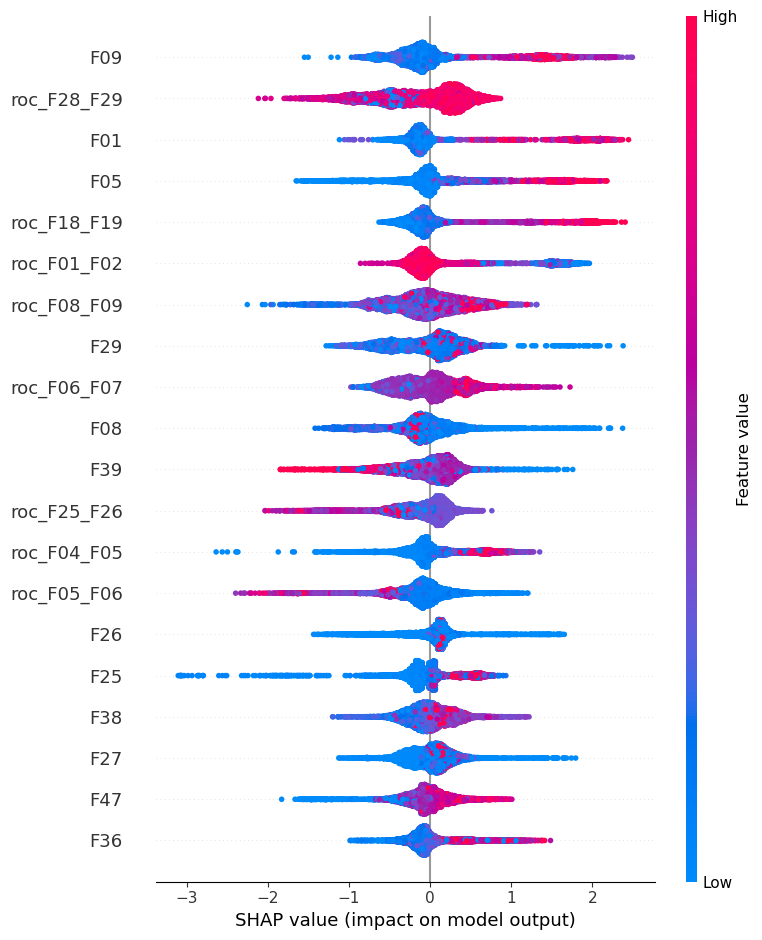

In [22]:
import shap as shp

def optimize_threshold(y_true, y_probs):
    
    # starting threshold and best score trackers
    best_thresh = 0.5
    best_f1 = 0.0
    
    # try multiple probability thresholds
    thresholds = np.arange(0.1, 0.9, 0.01)
    
    for thresh in thresholds:
        
        # convert probabilities to class predictions
        y_pred = (y_probs >= thresh).astype(int)
        
        # evaluate macro F1 score
        score = f1_score(y_true, y_pred, average='macro')
        
        # update best threshold if score improves
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    # predictions using the optimal threshold
    optimal_preds = (y_probs >= best_thresh).astype(int)
    
    # calculate final accuracy
    best_accuracy = accuracy_score(y_true, optimal_preds)
            
    print(f"\nOptimal Macro F1-score: {best_f1:.4f}\nAccuracy: {best_accuracy:.4f}\nAchieved at Threshold: {best_thresh:.2f}")
    
    # compute confusion matrix
    cm = confusion_matrix(y_true, optimal_preds)
    tn, fp, fn, tp = cm.ravel()
    
    print("\nConfusion Matrix")
    print(f"[{tn}  {fp}]")
    print(f"[{fn}  {tp}]")
    
    print("\nConfusion Matrix Components")
    print(f"True Negatives:{tn}")
    print(f"False Positives:{fp}")
    print(f"False Negatives:{fn}")
    print(f"True Positives:{tp}")
    
    return best_thresh


def my_shap(model, X_val):
    
    print("\nGenerating SHAP explanations using LightGBM base estimator")
    
    # extract the XGBoost model from stacking classifier
    xgb_model = model.named_estimators_['xgb']
    
    # create SHAP explainer
    explainer = shp.TreeExplainer(xgb_model)
    
    # compute SHAP values
    shap_values = explainer.shap_values(X_val)
    
    # handle binary-class output format
    shap_vals_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
    
    # generate summary plot
    shp.summary_plot(shap_vals_to_plot, X_val, show=False)
    
    # save figure to file
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=300)
    
    print("Saved SHAP visualization to 'shap_summary.png'")


print("\nOptimizing threshold & SHAP analysis")

# find optimal decision threshold
best_thresh = optimize_threshold(y_train, oof_probs)

# generate SHAP explanations
my_shap(last_model, last_X_val)

# convert averaged probabilities to final predictions
test_preds = (test_probs_averaged >= best_thresh).astype(int)

# prepare submission dataframe
submission = pd.DataFrame({
    'ID': test_ids,
    'CLASS': test_preds
})

# save submission file
save_path = "C://Users//komal//Documents//alrIEEEna_26_dataset//MLChallengeDataset//FINAL.csv"
submission.to_csv(save_path, index=False)